# TakeMeter — Fine-Tuning Starter Notebook
### AI201 · Project 3

This notebook walks you through fine-tuning a text classifier on your annotated dataset and comparing it to a zero-shot baseline.

**What this notebook does for you (infrastructure):**
- Tokenizes your dataset and prepares it for training
- Runs the fine-tuning pipeline with DistilBERT
- Computes evaluation metrics and generates a confusion matrix
- Runs the Groq baseline and compares both models

**What you do (the actual work):**
- Collect and annotate your 200+ examples (done before opening this notebook)
- Define your label map and upload your CSV
- Write your Groq classification prompt using your label definitions
- Analyze the output and write your evaluation report

---
**Before you start:** Make sure you are using a T4 GPU runtime.  
Go to **Runtime → Change runtime type → T4 GPU**, then click Save.

In [1]:
# Install any dependencies not pre-installed on Colab
!pip install -q groq python-dotenv
print("✅ Dependencies ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 11.8 MB/s eta 0:00:00
✅ Dependencies ready


In [2]:
import pandas as pd
import numpy as np
import json
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from datasets import Dataset
import warnings
warnings.filterwarnings("ignore")

print("✅ Imports complete")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✅ Imports complete
PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


---
## Section 1: Load Your Dataset

Upload your labeled CSV and define your label map.  
Your CSV must have at least two columns: `text` (the post/comment) and `label` (your string label).

In [6]:
# ── TODO ──────────────────────────────────────────────────────────────────
# Define YOUR label map below.
# Keys are the string labels in your CSV; values are integers starting at 0.
# Add or remove entries to match your actual labels (2–4 labels supported).
#
# The example below is ILLUSTRATIVE ONLY (the r/nba taxonomy from the project
# page). DELETE it and use your own community's labels — submitting the
# example unchanged will not pass.
# ────────────────────────────────────────────────────────────────────────

LABEL_MAP = {
    "diagnostic_explanation":  0,   # ← Replace with your first label
    "actionable_suggestion":  1,   # ← Replace with your second label
    "clarification_request":  2,   # ← Replace with your third label (remove if you have 2 labels)
    # "fourth_label": 3,  # ← Uncomment if you have a fourth label
}

# ── END TODO ──────────────────────────────────────────────────────────────

ID_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
NUM_LABELS = len(LABEL_MAP)
print(f"Labels: {LABEL_MAP}")
print(f"Number of labels: {NUM_LABELS}")

Labels: {'diagnostic_explanation': 0, 'actionable_suggestion': 1, 'clarification_request': 2}
Number of labels: 3


In [3]:
# Upload your CSV from your computer
from google.colab import files
print("Select your labeled dataset CSV file...")
uploaded = files.upload()
CSV_PATH = list(uploaded.keys())[0]
print(f"Uploaded: {CSV_PATH}")

Select your labeled dataset CSV file...


Saving takemeter_ai_reviewed_all_260.csv to takemeter_ai_reviewed_all_260.csv
Uploaded: takemeter_ai_reviewed_all_260.csv


In [7]:
# Load and validate your dataset
df = pd.read_csv(CSV_PATH)

# ── TODO (if needed) ──────────────────────────────────────────────────────
# If your CSV uses different column names, rename them here.
# Example: df = df.rename(columns={"post": "text", "category": "label"})
# ── END TODO ──────────────────────────────────────────────────────────────

print(f"Columns: {df.columns.tolist()}")
print(f"Total examples: {len(df)}")
print()
print("Label distribution:")
print(df["label"].value_counts())

# Validate all labels are in LABEL_MAP
unknown = set(df["label"].unique()) - set(LABEL_MAP.keys())
if unknown:
    print(f"\n⚠️  Labels in CSV not found in LABEL_MAP: {unknown}")
    print("Update your LABEL_MAP above to include all labels.")
else:
    print("\n✅ All labels match your LABEL_MAP")

# Convert string labels to integers
df["label_id"] = df["label"].map(LABEL_MAP)
df = df.dropna(subset=["label_id"])
df["label_id"] = df["label_id"].astype(int)

Columns: ['row_id', 'text', 'label', 'original_label', 'label_changed', 'notes', 'source_url', 'reviewed', 'source_type']
Total examples: 260

Label distribution:
label
diagnostic_explanation    134
clarification_request      71
actionable_suggestion      55
Name: count, dtype: int64

✅ All labels match your LABEL_MAP


---
## Section 2: Prepare Data for Training

Splits your dataset into train / validation / test sets and tokenizes the text.

In [8]:
# Train / val / test split — 70% / 15% / 15%
# Stratified so each split has roughly the same label distribution.
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["label_id"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["label_id"]
)

print(f"Train: {len(train_df)} examples")
print(f"Validation: {len(val_df)} examples")
print(f"Test: {len(test_df)} examples")
print()
print("Train label distribution:")
print(train_df["label"].value_counts())
print()
print("Test label distribution:")
print(test_df["label"].value_counts())

# Reset indices (needed for clean HuggingFace Dataset conversion)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

Train: 182 examples
Validation: 39 examples
Test: 39 examples

Train label distribution:
label
diagnostic_explanation    94
clarification_request     50
actionable_suggestion     38
Name: count, dtype: int64

Test label distribution:
label
diagnostic_explanation    20
clarification_request     10
actionable_suggestion      9
Name: count, dtype: int64


In [9]:
# Load tokenizer and tokenize all splits
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(examples):
    return tokenizer(examples["text"], truncation=True, max_length=256)

def make_dataset(df_split):
    ds = Dataset.from_pandas(
        df_split[["text", "label_id"]].rename(columns={"label_id": "labels"})
    )
    return ds.map(tokenize, batched=True)

train_dataset = make_dataset(train_df)
val_dataset   = make_dataset(val_df)
test_dataset  = make_dataset(test_df)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("✅ Tokenization complete")
print(f"Sample keys: {list(train_dataset[0].keys())}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/182 [00:00<?, ? examples/s]

Map:   0%|          | 0/39 [00:00<?, ? examples/s]

Map:   0%|          | 0/39 [00:00<?, ? examples/s]

✅ Tokenization complete
Sample keys: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']


---
## Section 3: Fine-Tune Your Model

Loads `distilbert-base-uncased` with a classification head and fine-tunes it on your training data.  
Training runs for 3 epochs and takes **5–15 minutes** on a T4 GPU.

> **Hyperparameter note:** The defaults below work well for datasets of 100–500 examples.  
> If you change any values, note what you changed and why in your README.

In [18]:
# Load DistilBERT with a classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID_TO_LABEL,
    label2id=LABEL_MAP,
)
print(f"✅ Model loaded: {MODEL_NAME}")
print(f"Output labels: {NUM_LABELS}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded: distilbert-base-uncased
Output labels: 3


In [16]:
# new
from sklearn.metrics import f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1_macro": f1_score(
            labels,
            predictions,
            average="macro",
            zero_division=0,
        ),
    }

In [11]:
#def compute_metrics(eval_pred):
    #logits, labels = eval_pred
    #predictions = np.argmax(logits, axis=-1)
    #return {"accuracy": accuracy_score(labels, predictions)}

In [17]:
# new
train_label_ids = (
    train_df["label"]
    .map(LABEL_MAP)
    .astype(int)
    .to_numpy()
)

class_counts = np.bincount(
    train_label_ids,
    minlength=NUM_LABELS,
)

class_weights = (
    len(train_label_ids) /
    (NUM_LABELS * class_counts)
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float,
)

print("Training class counts:")
for label_id in range(NUM_LABELS):
    print(
        ID_TO_LABEL[label_id],
        "count =", class_counts[label_id],
        "weight =", round(class_weights[label_id].item(), 3),
    )

Training class counts:
diagnostic_explanation count = 94 weight = 0.645
actionable_suggestion count = 38 weight = 1.596
clarification_request count = 50 weight = 1.213


In [24]:
#new
class WeightedTrainer(Trainer):
    def __init__(
        self,
        *args,
        class_weights=None,
        **kwargs,
    ):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None,
    ):
        labels = inputs["labels"]
        outputs = model(**inputs)
        logits = outputs["logits"]

        loss_function = torch.nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device)
        )

        loss = loss_function(
            logits.view(-1, model.config.num_labels),
            labels.view(-1),
        )

        if return_outputs:
            return loss, outputs

        return loss

In [26]:
# ── Hyperparameters ───────────────────────────────────────────────────────
# num_train_epochs  — passes through the training data; 3 is a good default
#                     for small datasets. Increase cautiously; more epochs
#                     risk overfitting on 200 examples.
# learning_rate     — 2e-5 is the standard starting point for fine-tuning
#                     BERT-family models. Lower → slower but more stable.
# per_device_train_batch_size — 16 fits T4 GPU comfortably.
#                     Reduce to 8 if you get out-of-memory errors.
# ─────────────────────────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir="./takemeter-model",
    #num_train_epochs=3,
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    #metric_for_best_model="accuracy",
    metric_for_best_model="f1_macro",
    logging_steps=10,
    report_to="none",
)

#trainer = Trainer(
    #model=model,
    #args=training_args,
    #train_dataset=train_dataset,
    #eval_dataset=val_dataset,
    #data_collator=data_collator,
    #compute_metrics=compute_metrics,
#)
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    class_weights=class_weights,
)

print("Starting fine-tuning... (5–15 minutes on T4 GPU)")
trainer.train()
print("\n✅ Fine-tuning complete")

Starting fine-tuning... (5–15 minutes on T4 GPU)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.105663,1.096394,0.512821,0.225989
2,1.086046,1.072308,0.487179,0.222222
3,1.052183,0.987693,0.717949,0.634259
4,0.977310,0.755582,0.871795,0.852137
5,0.645527,0.756851,0.743590,0.677479


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Fine-tuning complete


---
## Section 4: Evaluate Fine-Tuned Model on Test Set

Runs inference on your locked test set and generates metrics and a confusion matrix.  
These numbers go directly into your evaluation report.

In [27]:
# Run inference on the test set
print("Running inference on test set...")
ft_output = trainer.predict(test_dataset)
ft_pred_ids = np.argmax(ft_output.predictions, axis=-1)
ft_true_ids = ft_output.label_ids

ft_probs = torch.nn.functional.softmax(
    torch.tensor(ft_output.predictions), dim=-1
).numpy()

# Overall accuracy
ft_accuracy = accuracy_score(ft_true_ids, ft_pred_ids)
print(f"\n🎯 Fine-tuned model accuracy: {ft_accuracy:.3f}")

# Per-class metrics
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("\nPer-class metrics (fine-tuned model):")
print(classification_report(ft_true_ids, ft_pred_ids, target_names=label_names, zero_division=0))

Running inference on test set...



🎯 Fine-tuned model accuracy: 0.769

Per-class metrics (fine-tuned model):
                        precision    recall  f1-score   support

diagnostic_explanation       0.89      0.80      0.84        20
 actionable_suggestion       0.80      0.44      0.57         9
 clarification_request       0.62      1.00      0.77        10

              accuracy                           0.77        39
             macro avg       0.77      0.75      0.73        39
          weighted avg       0.80      0.77      0.76        39



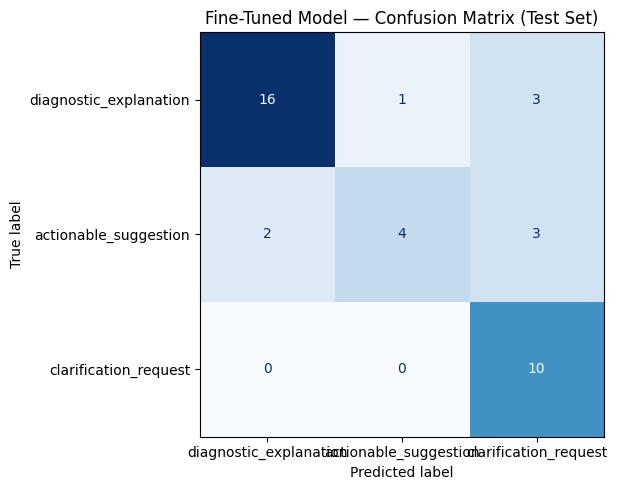

✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README


In [28]:
# Confusion matrix
cm = confusion_matrix(ft_true_ids, ft_pred_ids)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Fine-Tuned Model — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README")

In [30]:
# Print wrong predictions for your error analysis
# Review these carefully — pick 3 to analyze in depth in your README.

wrong_idx = np.where(ft_pred_ids != ft_true_ids)[0]
print(f"Wrong predictions: {len(wrong_idx)} / {len(ft_true_ids)}\n")

for i, idx in enumerate(wrong_idx[:15]):
    text = test_df.iloc[idx]["text"]
    true_label = ID_TO_LABEL[ft_true_ids[idx]]
    pred_label = ID_TO_LABEL[ft_pred_ids[idx]]
    confidence = ft_probs[idx][ft_pred_ids[idx]]
    print(f"--- #{i+1} ---")
    print(f"Text:      {text[:200]}{'...' if len(text) > 200 else ''}")
    print(f"True:      {true_label}")
    print(f"Predicted: {pred_label}  (confidence: {confidence:.2f})")
    print()

Wrong predictions: 9 / 39

--- #1 ---
Text:      Can't believe no one has posted this yet, but: Source: https://geekologie.com/2019/07/meanwhile-in-florida-a-car-with-a-window.php
True:      actionable_suggestion
Predicted: clarification_request  (confidence: 0.42)

--- #2 ---
Text:      @GdD - In most cases the problem is going to point one direction or the other. Most cases I'd suggest is over 99%. If I truly didn't know? I'd replace the master/slave, because it is a heck of a lot l...
True:      actionable_suggestion
Predicted: clarification_request  (confidence: 0.52)

--- #3 ---
Text:      @Pᴀᴜʟsᴛᴇʀ2 I've seen somewhat the opposite to this, I think - a piston-top that has been "built up" and given a sloped surface (in a way that doesn't interfere with the valves) though that may have be...
True:      diagnostic_explanation
Predicted: clarification_request  (confidence: 0.58)

--- #4 ---
Text:      Thanks! I'm a software engineer and I've been using StackExchange for years; never k

In [48]:
wrong_predictions_df = (
    classifications_df[
        classifications_df["correct"] == False
    ]
    .reset_index(drop=True)
)

wrong_predictions_df.to_csv(
    "wrong_predictions.csv",
    index=False,
)

print(
    f"✅ Created wrong_predictions.csv "
    f"with {len(wrong_predictions_df)} wrong predictions"
)

display(wrong_predictions_df)

✅ Created wrong_predictions.csv with 9 wrong predictions


,text,true_label,predicted_label,confidence,correct
0,"Can't believe no one has posted this yet, but:...",actionable_suggestion,clarification_request,0.4168,False
1,@GdD - In most cases the problem is going to p...,actionable_suggestion,clarification_request,0.5181,False
2,@Pᴀᴜʟsᴛᴇʀ2 I've seen somewhat the opposite to ...,diagnostic_explanation,clarification_request,0.5834,False
3,Thanks! I'm a software engineer and I've been ...,diagnostic_explanation,clarification_request,0.4633,False
4,The first thing I'd establish is to work out i...,actionable_suggestion,diagnostic_explanation,0.4370,False
5,Most of the time you won't need heavy braking ...,actionable_suggestion,diagnostic_explanation,0.5239,False
6,"The logic behind replacing the coolant, rather...",diagnostic_explanation,clarification_request,0.4853,False
7,"I've done it. I don't recommend it , unless th...",diagnostic_explanation,actionable_suggestion,0.4349,False
8,Place a cardboard box next to your car. If sci...,actionable_suggestion,clarification_request,0.4649,False


---
## Section 5: Baseline Classifier (Groq)

Runs your zero-shot baseline using `llama-3.3-70b-versatile`.  
You need to write the classification prompt using your label definitions.

In [31]:
from groq import Groq

# ── TODO: Add your Groq API key ───────────────────────────────────────────
# Recommended: use Colab Secrets so your key is never visible in the notebook.
#   1. Click the 🔑 icon in the left sidebar ("Secrets")
#   2. Add a secret named GROQ_API_KEY with your key as the value
#   3. Enable notebook access for the secret
#
# Then uncomment Option A below (and delete Option B).
#
# Option A — Colab Secrets (recommended):
from google.colab import userdata
GROQ_API_KEY = userdata.get("GROQ_API_KEY")
#
# Option B — paste directly (do not commit to GitHub):
#GROQ_API_KEY = "your_groq_api_key_here"

assert GROQ_API_KEY, (
    "GROQ_API_KEY not set — add it in the Colab Secrets panel (\U0001f511, left "
    "sidebar) and enable notebook access for this notebook, or use Option B above."
)

client = Groq(api_key=GROQ_API_KEY)
print("✅ Groq client initialized")

✅ Groq client initialized


In [32]:
# ── TODO: Write your classification prompt ────────────────────────────────
# Your prompt should:
#   1. Name your community and task
#   2. Define each label in plain language (copy from your planning.md)
#   3. Give one example post per label
#   4. Tell the model to output ONLY the label name — nothing else
#
# The model's response must match one of your label strings exactly,
# or the classify_with_groq() function below will mark it as unparseable.
#
# ─────────────────────────────────────────────────────────────────────────
# REPLACE the placeholders below with your actual prompt. As written, this
# skeleton will NOT classify correctly — you must fill it in.

SYSTEM_PROMPT = """
You are classifying public posts and comments from the Motor Vehicle Maintenance & Repair community.

Assign each post to exactly one of the following categories based on its main purpose.

diagnostic_explanation:
The post mainly explains a likely cause, diagnosis, technical mechanism, or reason why a vehicle problem occurs.
Example: "The battery voltage drops because a damaged cell cannot hold enough charge under load."

actionable_suggestion:
The post mainly recommends a concrete test, repair, maintenance step, safety action, or next procedure.
Example: "Check the battery voltage under load and clean the battery terminals before replacing the battery."

clarification_request:
The post mainly asks for missing symptoms, measurements, vehicle details, repair history, or other information needed before diagnosing the problem.
Example: "What is the year, make, model, and engine of the vehicle?"

Decision rules:
1. If the main purpose is asking for missing information, choose clarification_request.
2. Otherwise, if the main purpose is telling the user what action to take, choose actionable_suggestion.
3. Otherwise, if the main purpose is explaining what is happening or why, choose diagnostic_explanation.

Respond with ONLY one exact label name.
Do not explain your reasoning.
Do not add punctuation, quotation marks, or extra text.

Valid labels:
diagnostic_explanation
actionable_suggestion
clarification_request
""".strip()

print("Prompt length:", len(SYSTEM_PROMPT), "characters")

Prompt length: 1429 characters


In [33]:
def classify_with_groq(text):
    """Classify a single post. Returns a label string or None if unparseable."""
    try:
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": f"Classify this post:\n\n{text}"},
            ],
            temperature=0,
            max_tokens=20,
        )
        raw = response.choices[0].message.content.strip().lower()
        # Match the model's output to a label. Check longest labels first so a
        # label that is a substring of another (e.g. "recommendation" vs.
        # "strong_recommendation") can't be matched by mistake.
        for label in sorted(LABEL_MAP, key=len, reverse=True):
            if raw == label or label in raw:
                return label
        return None  # model output didn't match any known label
    except Exception as e:
        print(f"API error: {e}")
        return None


# Run baseline on test set
print(f"Running baseline on {len(test_df)} examples...")
print("(May take a few minutes — 0.1s delay between requests to respect free-tier limits)\n")

baseline_preds = []
for i, (_, row) in enumerate(test_df.iterrows()):
    pred = classify_with_groq(row["text"])
    baseline_preds.append(pred)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(test_df)} complete...")
    time.sleep(0.1)

none_count = baseline_preds.count(None)
if none_count > 0:
    print(f"\n⚠️  {none_count} responses could not be parsed.")
    print("Review your prompt — the model may not be outputting clean label names.")

Running baseline on 39 examples...
(May take a few minutes — 0.1s delay between requests to respect free-tier limits)

API error: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01kt5h9k27fk6aq125b8d4hyxa` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99984, Requested 376. Please try again in 5m11.039999999s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}
API error: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01kt5h9k27fk6aq125b8d4hyxa` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99984, Requested 389. Please try again in 5m22.272s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}
API error: Error code: 429 - {'error'

In [34]:
# Baseline metrics (exclude unparseable responses)
valid = [(p, t) for p, t in zip(baseline_preds, test_df["label_id"])
         if p is not None]
bl_pred_ids = [LABEL_MAP[p] for p, _ in valid]
bl_true_ids = [t for _, t in valid]

bl_accuracy = accuracy_score(bl_true_ids, bl_pred_ids)
print(f"🎯 Baseline accuracy: {bl_accuracy:.3f}  "
      f"(evaluated on {len(valid)}/{len(test_df)} parseable responses)")
print()
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("Per-class metrics (baseline):")
print(classification_report(bl_true_ids, bl_pred_ids, target_names=label_names, zero_division=0))

🎯 Baseline accuracy: 0.714  (evaluated on 7/39 parseable responses)

Per-class metrics (baseline):
                        precision    recall  f1-score   support

diagnostic_explanation       1.00      0.80      0.89         5
 actionable_suggestion       0.00      0.00      0.00         1
 clarification_request       0.33      1.00      0.50         1

              accuracy                           0.71         7
             macro avg       0.44      0.60      0.46         7
          weighted avg       0.76      0.71      0.71         7



---
## Section 6: Compare Results and Export

Side-by-side comparison of both models.  
Download the output files and commit them to your GitHub repo.

In [40]:
print("=" * 50)
print("RESULTS COMPARISON")
print("=" * 50)
print(f"{'Model':<35} {'Accuracy':>8}")
print("-" * 45)
print(f"{'Zero-shot baseline (Groq)':<35} {bl_accuracy:>8.3f}")
print(f"{'Fine-tuned DistilBERT':<35} {ft_accuracy:>8.3f}")
print("-" * 45)
delta = ft_accuracy - bl_accuracy
direction = "improvement" if delta >= 0 else "regression"
print(f"\nFine-tuning {direction}: {abs(delta):.3f}")
print()
print("Use these numbers in your README evaluation report.")

RESULTS COMPARISON
Model                               Accuracy
---------------------------------------------
Zero-shot baseline (Groq)              0.714
Fine-tuned DistilBERT                  0.769
---------------------------------------------

Fine-tuning improvement: 0.055

Use these numbers in your README evaluation report.


In [42]:
# Load the saved Groq checkpoint
baseline_results = pd.read_csv(CHECKPOINT_PATH)

baseline_results["test_index"] = pd.to_numeric(
    baseline_results["test_index"],
    errors="coerce",
)

baseline_results = (
    baseline_results
    .dropna(subset=["test_index"])
    .drop_duplicates(subset=["test_index"], keep="last")
    .sort_values("test_index")
)

# Use exactly the first 7 valid Groq predictions
valid_baseline = (
    baseline_results[
        baseline_results["predicted_label"].isin(LABEL_MAP)
    ]
    .head(7)
    .copy()
)

bl_true_ids = (
    valid_baseline["true_label"]
    .map(LABEL_MAP)
    .astype(int)
    .to_numpy()
)

bl_pred_ids = (
    valid_baseline["predicted_label"]
    .map(LABEL_MAP)
    .astype(int)
    .to_numpy()
)

partial_baseline_accuracy = accuracy_score(
    bl_true_ids,
    bl_pred_ids,
)

partial_coverage = len(valid_baseline) / len(test_df)

print("=" * 65)
print("RESULTS COMPARISON")
print("=" * 65)
print(f"{'Model':<42}{'Accuracy':>10}{'Coverage':>12}")
print("-" * 65)

print(
    f"{'Groq zero-shot baseline (partial)':<42}"
    f"{partial_baseline_accuracy:>10.3f}"
    f"{len(valid_baseline):>6}/{len(test_df)}"
)

print(
    f"{'Fine-tuned DistilBERT':<42}"
    f"{ft_accuracy:>10.3f}"
    f"{len(test_df):>6}/{len(test_df)}"
)

print("-" * 65)

print(
    "\n⚠️ Groq is a provisional partial baseline "
    "because only 7 of 39 examples were evaluated."
)

RESULTS COMPARISON
Model                                       Accuracy    Coverage
-----------------------------------------------------------------
Groq zero-shot baseline (partial)              0.714     7/39
Fine-tuned DistilBERT                          0.769    39/39
-----------------------------------------------------------------

⚠️ Groq is a provisional partial baseline because only 7 of 39 examples were evaluated.


In [43]:
results = {
    "community": "Motor Vehicle Maintenance & Repair",
    "labels": LABEL_MAP,
    "model": "distilbert-base-uncased",

    "fine_tuned_model": {
        "accuracy": round(float(ft_accuracy), 4),
        "test_examples": int(len(test_df)),
        "coverage": "39/39",
        "macro_f1": 0.73,
        "complete": True,
    },

    "groq_partial_baseline": {
        "model": "llama-3.3-70b-versatile",
        "accuracy_on_completed_examples": round(
            float(partial_baseline_accuracy),
            4,
        ),
        "completed_examples": int(len(valid_baseline)),
        "total_test_examples": int(len(test_df)),
        "coverage": f"{len(valid_baseline)}/{len(test_df)}",
        "coverage_rate": round(float(partial_coverage), 4),
        "complete": False,
        "limitation": (
            "Groq free-tier token limit prevented evaluation "
            "on the complete test set."
        ),
    },
}

with open(
    "evaluation_results.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        results,
        file,
        indent=2,
    )

valid_baseline.to_csv(
    "groq_partial_baseline_predictions.csv",
    index=False,
)

print("✅ Created evaluation_results.json")
print("✅ Created groq_partial_baseline_predictions.csv")
print("✅ confusion_matrix.png should already exist")

✅ Created evaluation_results.json
✅ Created groq_partial_baseline_predictions.csv
✅ confusion_matrix.png should already exist


In [44]:
# Save results JSON — commit to your GitHub repo and reference in README
results = {
    "baseline_accuracy": round(bl_accuracy, 4),
    "finetuned_accuracy": round(ft_accuracy, 4),
    "improvement": round(ft_accuracy - bl_accuracy, 4),
    "test_set_size": len(test_df),
    "label_map": LABEL_MAP,
    "model": MODEL_NAME,
}
with open("evaluation_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("✅ Files ready to download:")
print("   evaluation_results.json  — metrics for your README")
print("   confusion_matrix.png     — include in your README")
print()
print("Download via: Files panel (📁) on the left → right-click → Download")

✅ Files ready to download:
   evaluation_results.json  — metrics for your README
   confusion_matrix.png     — include in your README

Download via: Files panel (📁) on the left → right-click → Download


In [47]:
# Re-run inference to recreate all required variables
print("Running inference again...")

test_output = trainer.predict(test_dataset)

test_logits = test_output.predictions
test_true_ids = test_output.label_ids
test_pred_ids = np.argmax(test_logits, axis=-1)

# Convert logits to confidence probabilities
test_probabilities = torch.softmax(
    torch.tensor(test_logits),
    dim=-1,
).numpy()

classification_rows = []

for index in range(len(test_df)):
    true_id = int(test_true_ids[index])
    predicted_id = int(test_pred_ids[index])

    classification_rows.append({
        "text": test_df.iloc[index]["text"],
        "true_label": ID_TO_LABEL[true_id],
        "predicted_label": ID_TO_LABEL[predicted_id],
        "confidence": round(
            float(test_probabilities[index][predicted_id]),
            4,
        ),
        "correct": true_id == predicted_id,
    })

classifications_df = pd.DataFrame(classification_rows)

print("Total:", len(classifications_df))
print("Correct:", int(classifications_df["correct"].sum()))
print("Wrong:", int((~classifications_df["correct"]).sum()))

# Select 3 correct and 2 incorrect examples
correct_examples = (
    classifications_df[classifications_df["correct"]]
    .sort_values("confidence", ascending=False)
    .head(3)
)

incorrect_examples = (
    classifications_df[~classifications_df["correct"]]
    .sort_values("confidence", ascending=False)
    .head(2)
)

sample_df = pd.concat(
    [correct_examples, incorrect_examples],
    ignore_index=True,
)

display(
    sample_df[
        [
            "text",
            "true_label",
            "predicted_label",
            "confidence",
            "correct",
        ]
    ]
)

sample_df.to_csv(
    "sample_classifications.csv",
    index=False,
)

print("✅ Created sample_classifications.csv")

Running inference again...


Total: 39
Correct: 30
Wrong: 9


,text,true_label,predicted_label,confidence,correct
0,By oil rag do you mean even a microfiber cloth...,clarification_request,clarification_request,0.6345,True
1,"Thank you!!! One last question, do I have to w...",clarification_request,clarification_request,0.6284,True
2,Welcome to Motor Vehicle Maintenance & Repair!...,clarification_request,clarification_request,0.6220,True
3,@Pᴀᴜʟsᴛᴇʀ2 I've seen somewhat the opposite to ...,diagnostic_explanation,clarification_request,0.5834,False
4,Most of the time you won't need heavy braking ...,actionable_suggestion,diagnostic_explanation,0.5239,False


✅ Created sample_classifications.csv
